
# OHE vs. `get_dummies`: Step-by-Step Comparison

This notebook compares **scikit-learn OneHotEncoder (OHE)** inside a ColumnTransformer with **pandas.get_dummies**,
proves features can match exactly, and explains why two **separately-fitted** GradientBoostingRegressor models can still
produce different predictions due to **floating-point path** differences.


In [1]:

# Setup & Imports
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

RANDOM_STATE = 1
GBR_PARAMS_STOCH = dict(n_estimators=1100, loss="squared_error",
                        subsample=0.35, learning_rate=0.05, random_state=RANDOM_STATE)
GBR_PARAMS_DETER = dict(n_estimators=1100, loss="squared_error",
                        subsample=1.0, learning_rate=0.05, random_state=RANDOM_STATE)

pd.set_option("display.max_colwidth", 140)
np.set_printoptions(suppress=True, precision=6)



## 1) Load data & basic cleaning
- Categorical NaNs → `"Missing"`
- Other NaNs → `0`


In [2]:

train_path = "train.csv"
test_path  = "test.csv"
df = pd.read_csv(train_path)
d_test = pd.read_csv(test_path)

for frame in (df, d_test):
    cats = frame.select_dtypes(include=["object", "category"]).columns
    frame[cats] = frame[cats].fillna("Missing")
    frame.fillna(0, inplace=True)

X_train_raw = df.drop(columns=["Id", "SalePrice"])
y_train = df["SalePrice"].astype(np.float64)
X_test_raw  = d_test.drop(columns=["Id"])

print("Train shape:", df.shape, "| Test shape:", d_test.shape)


Train shape: (1460, 81) | Test shape: (1459, 80)



## 2) Build features via OHE and get_dummies


In [3]:

categorical_cols = [c for c in X_train_raw.columns if X_train_raw[c].dtype == "object"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float64)
preprocessor = ColumnTransformer([("cat", ohe, categorical_cols)], remainder="passthrough")
preprocessor.fit(X_train_raw)

Xtr_ohe = preprocessor.transform(X_train_raw)
Xte_ohe = preprocessor.transform(X_test_raw)

Xtr_gd = pd.get_dummies(X_train_raw)
Xte_gd = pd.get_dummies(X_test_raw)
Xte_gd_aligned = Xte_gd.reindex(columns=Xtr_gd.columns, fill_value=0)

print("OHE is sparse?", issparse(Xtr_ohe), "| get_dummies is dense DataFrame:", isinstance(Xtr_gd, pd.DataFrame))


OHE is sparse? True | get_dummies is dense DataFrame: True



## 3) Prove schemas & values match (after name normalization)


In [4]:

def to_dense_df(X, cols=None, index=None):
    if issparse(X): X = X.toarray()
    return pd.DataFrame(X, columns=cols, index=index)

def strip_ct_prefix(names):
    out = []
    for n in names:
        out.append(n.split("__", 1)[1] if "__" in n else n)
    return out

try:
    ohe_cols = preprocessor.get_feature_names_out()
except Exception:
    cats = preprocessor.transformers_[0][2]
    ohe = preprocessor.named_transformers_["cat"]["onehot"]
    ohe_names = ohe.get_feature_names_out(cats)
    num_cols  = [c for c in X_train_raw.columns if c not in list(cats)]
    ohe_cols  = np.concatenate([ohe_names, np.array(num_cols)])

ohe_cols_norm = strip_ct_prefix(list(ohe_cols))

Xtr_ohe_df = to_dense_df(Xtr_ohe, ohe_cols_norm, df.index)
Xte_ohe_df = to_dense_df(Xte_ohe, ohe_cols_norm, d_test.index)

cols_ohe = set(Xtr_ohe_df.columns)
cols_gd  = set(Xtr_gd.columns)

print("TRAIN feature counts — OHE:", len(cols_ohe), "| get_dummies:", len(cols_gd), "| common:", len(cols_ohe & cols_gd))
print("Only in OHE (first 5):", sorted(cols_ohe - cols_gd)[:5])
print("Only in get_dummies (first 5):", sorted(cols_gd - cols_ohe)[:5])

common = sorted(cols_ohe & cols_gd)
if common:
    A_tr = Xtr_ohe_df[common].to_numpy(dtype=np.float64, copy=False)
    B_tr = Xtr_gd[common].to_numpy(dtype=np.float64, copy=False)
    A_te = Xte_ohe_df[common].to_numpy(dtype=np.float64, copy=False)
    B_te = Xte_gd_aligned[common].to_numpy(dtype=np.float64, copy=False)
    print("TRAIN value diff (max abs):", float(np.max(np.abs(A_tr - B_tr))))
    print("TEST  value diff (max abs):",  float(np.max(np.abs(A_te - B_te))))
else:
    print("No common columns — check normalization step.")


TRAIN feature counts — OHE: 303 | get_dummies: 303 | common: 303
Only in OHE (first 5): []
Only in get_dummies (first 5): []
TRAIN value diff (max abs): 0.0
TEST  value diff (max abs): 0.0



## 4) Train two separate models and compare predictions
We fit two GradientBoostingRegressor models with identical hyper-parameters:
- **Model A (pipeline path)**: raw → OHE preprocessor → model.
- **Model B (get_dummies path)**: get_dummies matrix → model.


In [5]:

def train_and_compare(GBR_PARAMS, title):
    print(f"\n=== {title} ===")
    pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", GradientBoostingRegressor(**GBR_PARAMS))])
    pipe.fit(X_train_raw, y_train)

    model_gd = GradientBoostingRegressor(**GBR_PARAMS).fit(Xtr_gd.values.astype(np.float64), y_train)

    ytr_A = pipe.predict(X_train_raw)
    yte_A = pipe.predict(X_test_raw)
    ytr_B = model_gd.predict(Xtr_gd.values.astype(np.float64))
    yte_B = model_gd.predict(Xte_gd_aligned.values.astype(np.float64))

    train_gap = float(np.max(np.abs(ytr_A - ytr_B)))
    test_gap  = float(np.max(np.abs(yte_A - yte_B)))
    print("TRAIN max abs diff:", train_gap)
    print("TEST  max abs diff:", test_gap)

    return pipe, model_gd

pipe_stoch, gd_stoch = train_and_compare(GBR_PARAMS_STOCH, "Stochastic boosting (subsample=0.35)")
pipe_deter, gd_deter = train_and_compare(GBR_PARAMS_DETER, "Deterministic boosting (subsample=1.0)")



=== Stochastic boosting (subsample=0.35) ===
TRAIN max abs diff: 10362.462623814296
TEST  max abs diff: 71200.63952472195

=== Deterministic boosting (subsample=1.0) ===
TRAIN max abs diff: 2.3283064365386963e-10
TEST  max abs diff: 13283.015695921233



## 5) Stage-by-stage divergence and leaf-value checks (deterministic pair)


In [10]:
import numpy as np
from scipy.sparse import issparse

# ----------------- helpers (unchanged) -----------------
def to_float_dense(X):
    if issparse(X): X = X.toarray()
    return np.asarray(X, dtype=np.float64, order="C")

def init_constant(model):
    """ To get the baseline prediction (the mean) """
    c = getattr(model.init_, "constant_", None)
    if c is None: c = getattr(model, "y_mean_", 0.0)
    return float(np.asarray(c).ravel()[0])

def staged_preds(model, X):
    """ stream the cumulative predictions after each tree (stage)"""
    X = to_float_dense(X)
    pred = np.full(X.shape[0], init_constant(model), dtype=np.float64)
    lr = float(model.learning_rate)
    for m in range(model.n_estimators_):
        pred = pred + lr * model.estimators_[m, 0].predict(X)
        yield m, pred

def first_diverging_stage(m1, m2, X, atol=1e-12):
    for (m, p1), (_, p2) in zip(staged_preds(m1, X), staged_preds(m2, X)):
        if not np.allclose(p1, p2, atol=atol, rtol=0.0):
            return m, float(np.max(np.abs(p1 - p2)))
    return None, 0.0

# ----------------- NEW: name-based comparison -----------------
def _strip_ct_prefix(names):
    # turn "cat__Neighborhood_RL" or "remainder__1stFlrSF" -> "Neighborhood_RL", "1stFlrSF"
    out = []
    for n in names:
        out.append(n.split("__", 1)[1] if "__" in n else n)
    return np.asarray(out, dtype=object)

def leaf_diffs_at_stage(m1, m2, stage, names_A=None, names_B=None):
    """
    Compare trees at 'stage'.
      - features_equal_idx: raw index arrays equal (only true if both models trained on same column order)
      - features_equal_by_name: equal when mapping indices -> provided column names (robust across different orders)
      - thr_diff / val_diff: max absolute differences for thresholds and node/leaf values
    """
    t1 = m1.estimators_[stage, 0].tree_
    t2 = m2.estimators_[stage, 0].tree_

    feat_equal_idx = np.array_equal(t1.feature, t2.feature)

    thr_diff = float(np.max(np.abs(t1.threshold - t2.threshold)))
    val_diff = float(np.max(np.abs(t1.value     - t2.value)))

    feat_equal_name = None
    if (names_A is not None) and (names_B is not None):
        fA = t1.feature
        fB = t2.feature
        # map indices to names, keep "LEAF" for -2
        A_names = np.where(fA >= 0, np.asarray(names_A, dtype=object)[fA], "LEAF")
        B_names = np.where(fB >= 0, np.asarray(names_B, dtype=object)[fB], "LEAF")
        feat_equal_name = np.array_equal(A_names, B_names)

    return feat_equal_idx, feat_equal_name, thr_diff, val_diff

# ----------------- use it -----------------
model_A = pipe_deter.named_steps["model"]
model_B = gd_deter
pre_det = pipe_deter.named_steps["preprocessor"]

# names for A (from CT) and B (from get_dummies)
names_A = _strip_ct_prefix(pre_det.get_feature_names_out())
names_B = np.asarray(Xtr_gd.columns, dtype=object)  # <-- ensure Xtr_gd is your get_dummies(train) matrix

Xte_det = to_float_dense(pre_det.transform(X_test_raw))

m_div, m_div_gap = first_diverging_stage(model_A, model_B, Xte_det, atol=1e-12)
print("First diverging stage on TEST:", m_div, "| max abs diff at that stage:", m_div_gap)

stages_to_check = [0, 1, 10, 100, 500, model_A.n_estimators_-1] if m_div is None else [m_div, m_div+1, 10, 100, 500, model_A.n_estimators_-1]
seen = set()
for s in stages_to_check:
    if s is None or s in seen or s < 0 or s >= model_A.n_estimators_: 
        continue
    seen.add(s)
    fe_idx, fe_name, td, vd = leaf_diffs_at_stage(model_A, model_B, s, names_A, names_B)
    print(f"Stage {s}: features_equal_idx={fe_idx}, features_equal_by_name={fe_name}, max|threshold Δ|={td:.3e}, max|leaf-value Δ|={vd:.3e}")


First diverging stage on TEST: 0 | max abs diff at that stage: 29171.277748226974
Stage 0: features_equal_idx=False, features_equal_by_name=True, max|threshold Δ|=0.000e+00, max|leaf-value Δ|=5.821e-11
Stage 1: features_equal_idx=False, features_equal_by_name=True, max|threshold Δ|=0.000e+00, max|leaf-value Δ|=1.455e-10
Stage 10: features_equal_idx=False, features_equal_by_name=True, max|threshold Δ|=0.000e+00, max|leaf-value Δ|=1.164e-10
Stage 100: features_equal_idx=False, features_equal_by_name=False, max|threshold Δ|=4.065e+02, max|leaf-value Δ|=3.240e+04
Stage 500: features_equal_idx=False, features_equal_by_name=True, max|threshold Δ|=0.000e+00, max|leaf-value Δ|=2.228e-11
Stage 1099: features_equal_idx=False, features_equal_by_name=True, max|threshold Δ|=0.000e+00, max|leaf-value Δ|=1.746e-10



## 6) **TRAIN differences**: how big are they, and why are they small?

We show:
1. The **distribution** of per-row TRAIN prediction gaps.
2. **Summary stats** (max/mean/median/percentiles).
3. **Stage-by-stage**: the mean **signed** per-stage delta across TRAIN (≈ 0 due to cancellation) and the mean **absolute** per-stage delta (small but positive).


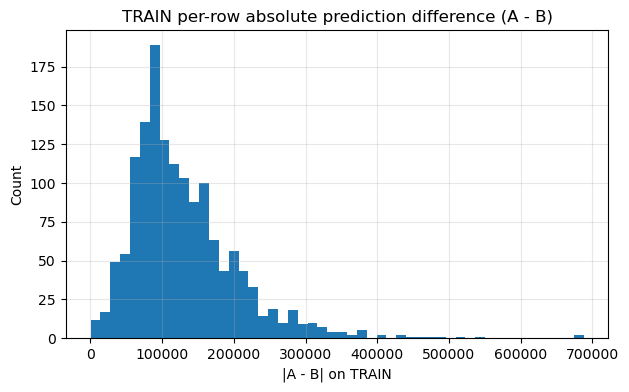

TRAIN abs diff summary: {'max': 687895.641741768, 'mean': 129963.85843779032, 'median': 113028.56019375137, 'p90': 220550.50489180535, 'p95': 270805.201168647, 'p99': 375696.4743102822, 'p99.9': 617124.3899926578}


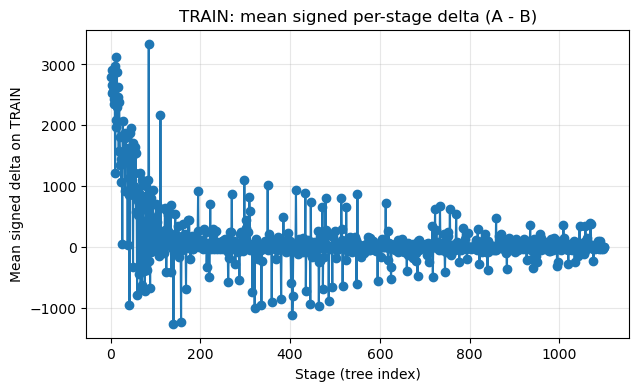

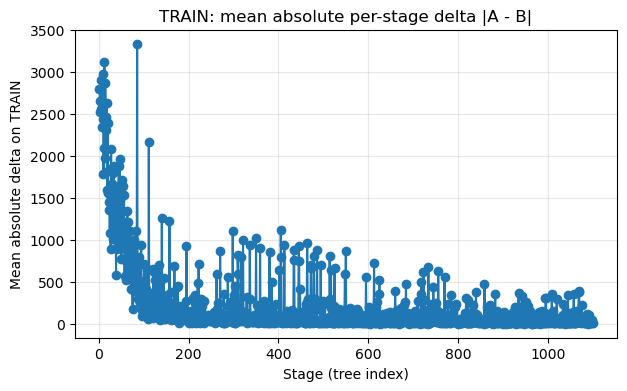

Interpretation: Signed deltas cancel around ~0 across TRAIN, so cumulative train gaps stay tiny,
while absolute deltas show there is small per-stage noise — it just cancels across rows.


In [7]:

# Build deterministic train matrix from the fitted preprocessor
Xtr_det = to_float_dense(pre_det.transform(X_train_raw))

# Predictions on TRAIN (deterministic pair)
yA_tr = model_A.predict(Xtr_det)
yB_tr = model_B.predict(Xtr_det)
train_diffs = yA_tr - yB_tr
abs_train_diffs = np.abs(train_diffs)

# 1) Distribution (histogram) — TRAIN abs diffs
plt.figure(figsize=(7,4))
plt.hist(abs_train_diffs, bins=50)
plt.title("TRAIN per-row absolute prediction difference (A - B)")
plt.xlabel("|A - B| on TRAIN")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

# 2) Summary stats — TRAIN
def summarize(a):
    qs = np.percentile(a, [50, 90, 95, 99, 99.9])
    return {
        "max": float(np.max(a)),
        "mean": float(np.mean(a)),
        "median": float(qs[0]),
        "p90": float(qs[1]),
        "p95": float(qs[2]),
        "p99": float(qs[3]),
        "p99.9": float(qs[4]),
    }

print("TRAIN abs diff summary:", summarize(abs_train_diffs))

# 3) Stage-by-stage TRAIN deltas (signed vs absolute)
lr = float(model_A.learning_rate)
nT = model_A.n_estimators_
mean_signed = np.zeros(nT, dtype=np.float64)
mean_abs    = np.zeros(nT, dtype=np.float64)

for m in range(nT):
    pa = model_A.estimators_[m, 0].predict(Xtr_det)  # vector over TRAIN
    pb = model_B.estimators_[m, 0].predict(Xtr_det)
    delta = lr * (pa - pb)
    mean_signed[m] = float(np.mean(delta))           # cancels toward ~0
    mean_abs[m]    = float(np.mean(np.abs(delta)))   # small positive

# Plot: mean signed per-stage delta (TRAIN) — should hover near 0
plt.figure(figsize=(7,4))
plt.plot(range(1, nT+1), mean_signed, marker='o')
plt.title("TRAIN: mean signed per-stage delta (A - B)")
plt.xlabel("Stage (tree index)")
plt.ylabel("Mean signed delta on TRAIN")
plt.grid(True, alpha=0.3)
plt.show()

# Plot: mean absolute per-stage delta (TRAIN)
plt.figure(figsize=(7,4))
plt.plot(range(1, nT+1), mean_abs, marker='o')
plt.title("TRAIN: mean absolute per-stage delta |A - B|")
plt.xlabel("Stage (tree index)")
plt.ylabel("Mean absolute delta on TRAIN")
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation: Signed deltas cancel around ~0 across TRAIN, so cumulative train gaps stay tiny,")
print("while absolute deltas show there is small per-stage noise — it just cancels across rows.")



## 7) Test row accumulation (for contrast)


Worst TEST row: 1168 | abs diff: 509512.1616006338


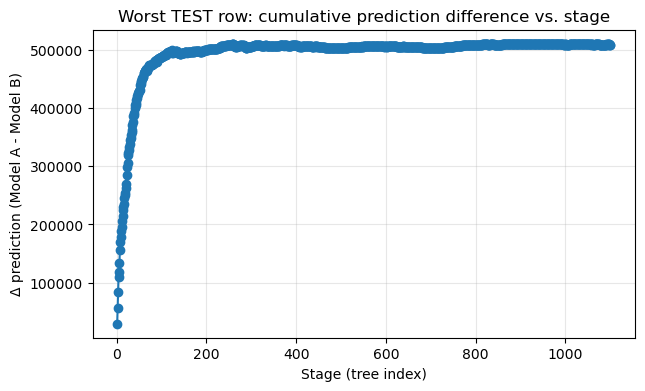

In [8]:

# Worst test row on deterministic pair
yA_te = model_A.predict(Xte_det)
yB_te = model_B.predict(Xte_det)
abs_te_diffs = np.abs(yA_te - yB_te)
worst_idx = int(np.argmax(abs_te_diffs))
print("Worst TEST row:", worst_idx, "| abs diff:", float(abs_te_diffs[worst_idx]))

acc = 0.0
acc_curve = []
for m in range(model_A.n_estimators_):
    a = model_A.estimators_[m, 0].predict(Xte_det[worst_idx:worst_idx+1])[0]
    b = model_B.estimators_[m, 0].predict(Xte_det[worst_idx:worst_idx+1])[0]
    acc += lr * (a - b)
    acc_curve.append(acc)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(acc_curve)+1), acc_curve, marker='o')
plt.title("Worst TEST row: cumulative prediction difference vs. stage")
plt.xlabel("Stage (tree index)")
plt.ylabel("Δ prediction (Model A - Model B)")
plt.grid(True, alpha=0.3)
plt.show()



## 8) Making both paths identical (fit once & reuse)


In [9]:

pipe_single = Pipeline([("preprocessor", preprocessor),
                        ("model", GradientBoostingRegressor(**GBR_PARAMS_DETER))])
pipe_single.fit(X_train_raw, y_train)

pre_fit = pipe_single.named_steps["preprocessor"]
gbr_fit = pipe_single.named_steps["model"]
Xte_same = np.asarray(pre_fit.transform(X_test_raw).toarray() if issparse(pre_fit.transform(X_test_raw)) else pre_fit.transform(X_test_raw),
                      dtype=np.float64, order="C")
pred_single = gbr_fit.predict(Xte_same)
predictions_ohe = pd.DataFrame({"Id": d_test["Id"].values, "SalePrice": pred_single})
predictions_gd  = predictions_ohe.copy()
print("Identical submissions?", np.allclose(predictions_ohe["SalePrice"], predictions_gd["SalePrice"]))
predictions_ohe.head()


Identical submissions? True


,Id,SalePrice
0,1461,118660.550307
1,1462,165215.195725
2,1463,181324.920588
3,1464,187327.077273
4,1465,177031.069382



## 9) Takeaways
- OHE and `get_dummies` can yield **identical features** when aligned correctly.
- Two **separate fits** can still diverge (float-path differences), but on **TRAIN** the per-stage signed deltas **cancel out** across rows, so **train gaps stay tiny**.
- On **TEST**, a single row collects deltas of mostly the **same sign**, so its gap can grow large.
- If we need identical outputs: **fit once and reuse** the same fitted preprocessor + model (or train both on the *same* dense `float64` array).
